## 1. Importing Libraries

In [2]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression

## 2. Importing Dataset

In [4]:
cars_data = pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Performing initial Investigation

In [5]:
cars_data.shape

(81, 5)

In [6]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [7]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [8]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Checking for assumptions

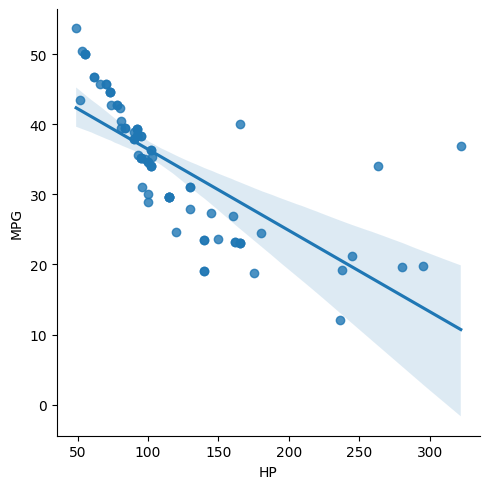

In [9]:
sns.lmplot(data= cars_data, x = "HP" , y = "MPG")

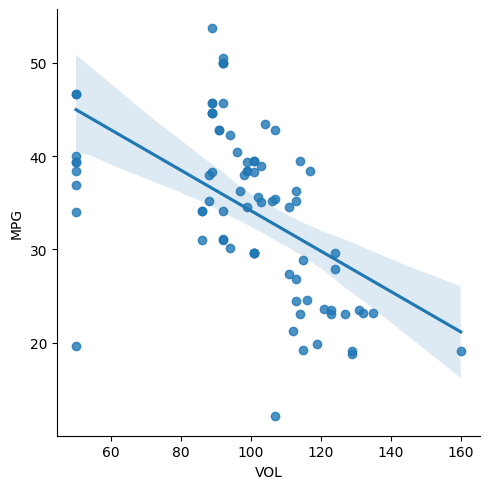

In [10]:
sns.lmplot( data = cars_data, x="VOL",y="MPG")

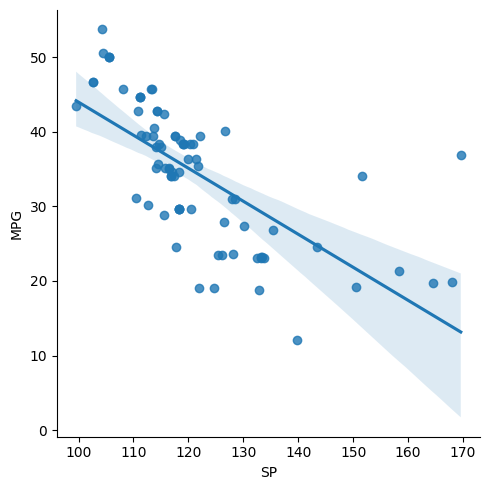

In [11]:
sns.lmplot( data = cars_data, x="SP",y="MPG")

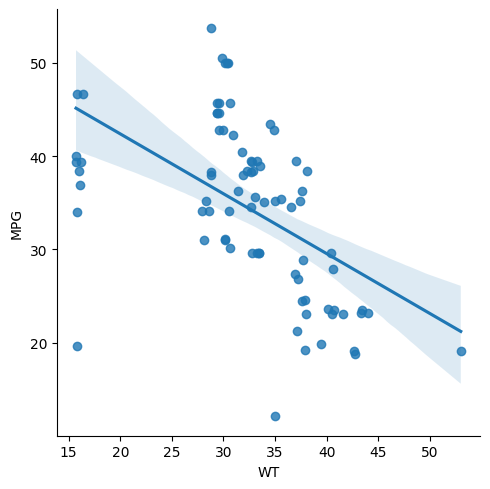

In [12]:
sns.lmplot( data = cars_data, x="WT",y="MPG")

### Linearity Test 1 failed

## Test 2 : Normality Test

(array([ 1.,  6., 10.,  4., 10., 15., 17.,  8.,  5.,  5.]),
 array([12.10126289, 16.26120474, 20.42114659, 24.58108844, 28.74103029,
        32.90097213, 37.06091398, 41.22085583, 45.38079768, 49.54073953,
        53.70068138]),
 <BarContainer object of 10 artists>)

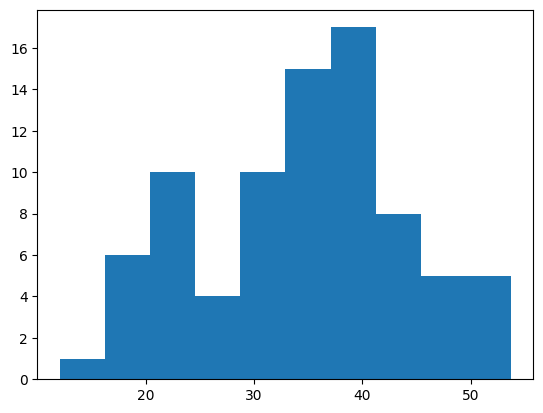

In [13]:
plt.hist(x = "MPG", data = cars_data)

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

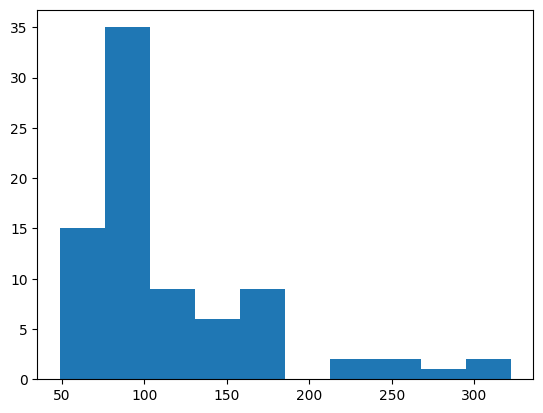

In [14]:
plt.hist(x = "HP", data= cars_data)

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

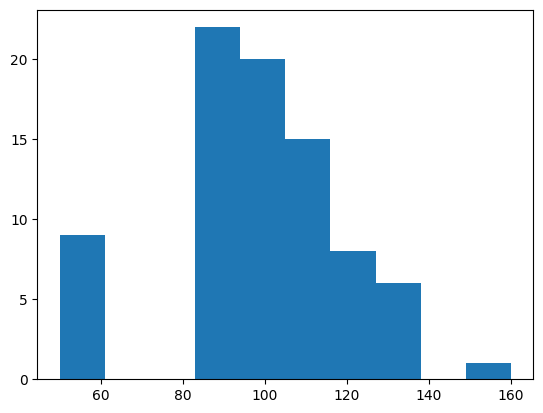

In [15]:
plt.hist(x = "VOL", data= cars_data)

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

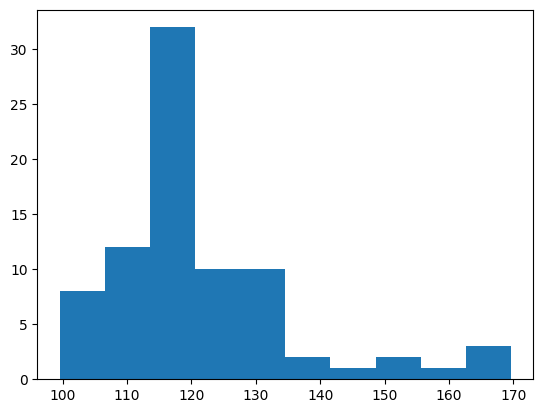

In [16]:
plt.hist(x = "SP", data= cars_data)

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

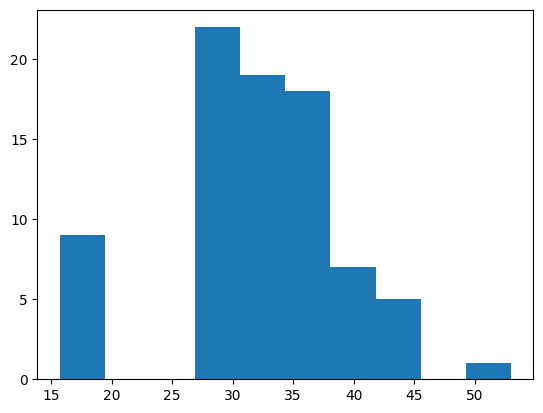

In [17]:
plt.hist(x = "WT", data = cars_data)

<function matplotlib.pyplot.show(close=None, block=None)>

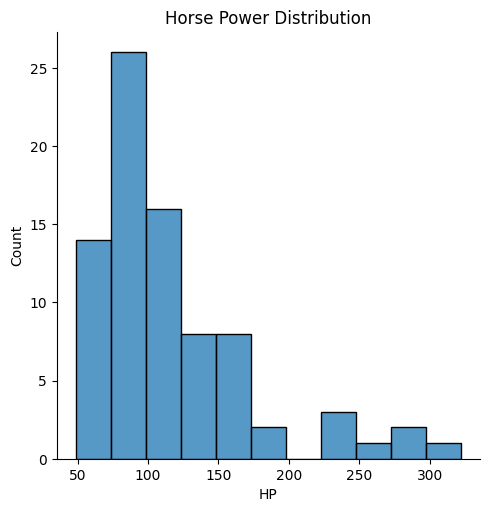

In [18]:
sns.displot(cars_data["HP"])
plt.title("Horse Power Distribution")
plt.show

## Test 2 - Normality test failed

## Test 3 - Multicollinearity Test

In [20]:
corr_matrix = cars_data.corr()

<Axes: >

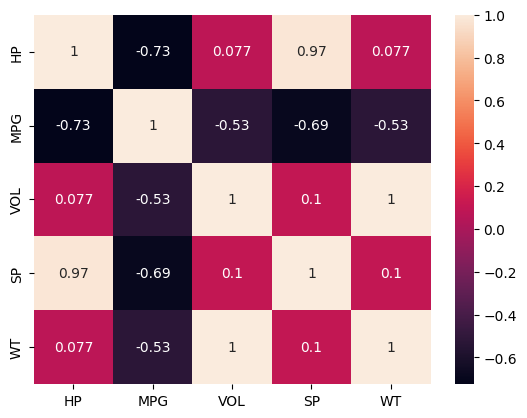

In [21]:
sns.heatmap(corr_matrix,annot=True)

## There is multicollinearity in the data

## Test - 4 

## Auto Regression - Dependency on time in the inputs

## Test - 4 - Auto Regression Passed

## Input Segregation

In [22]:
X = cars_data[["HP","VOL","SP","WT"]]

In [23]:
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [25]:
y = cars_data["MPG"]

In [26]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## 5. Model Building

In [27]:
linear_model = LinearRegression()

## 6. Model Training

In [28]:
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
